In [14]:
import numpy
print(numpy.__version__)

1.24.4


In [18]:
import pandas as pd
import numpy as np
np.bool = bool  # temporary compatibility shim
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load train.csv
data_dir = Path("../data")
train_df = pd.read_csv(data_dir / "train.csv", index_col=0, parse_dates=True)

print(f"Train data shape: {train_df.shape}")
print(f"Date range: {train_df.index.min()} to {train_df.index.max()}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\nFirst few rows:")
train_df.head()


Train data shape: (1916, 68)
Date range: 2015-01-02 00:00:00 to 2022-08-01 00:00:00

Columns: ['Close', 'Open', 'High', 'Low', 'Volume', 'Change_Pct', 'Returns', 'Log_Returns', 'MA_5', 'Price_MA_5_Ratio', 'MA_10', 'Price_MA_10_Ratio', 'MA_20', 'Price_MA_20_Ratio', 'MA_50', 'Price_MA_50_Ratio', 'MA_100', 'Price_MA_100_Ratio', 'MA_200', 'Price_MA_200_Ratio', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'High_Low_Ratio', 'Close_Open_Ratio', 'High_Close_Ratio', 'Low_Close_Ratio', 'High_5', 'Low_5', 'Close_High_5_Ratio', 'Close_Low_5_Ratio', 'High_10', 'Low_10', 'Close_High_10_Ratio', 'Close_Low_10_Ratio', 'High_20', 'Low_20', 'Close_High_20_Ratio', 'Close_Low_20_Ratio', 'Returns_Lag_1', 'Returns_Lag_2', 'Returns_Lag_3', 'Returns_Lag_5', 'Returns_Lag_10', 'Volume_MA_20', 'Volume_Ratio', 'Price_Volume', 'Year', 'Month', 'DayOfWeek', 'DayOfMonth', 'Trend_5', 'Tre

,Close,Open,High,Low,Volume,Change_Pct,Returns,Log_Returns,MA_5,Price_MA_5_Ratio,...,Year,Month,DayOfWeek,DayOfMonth,Trend_5,Trend_10,Trend_20,Forward_Return_30,Target_30d_Up,Target
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,1869.00,1856.75,1876.25,1835.0,2920.0,0.0066,0.000000,0.000000,0.00,0.000000,...,2015,1,4,2,0,0,0,-0.014714,0,0
2015-01-05,1841.50,1870.25,1878.50,1840.0,3380.0,-0.0147,-0.014714,-0.014823,0.00,0.000000,...,2015,1,0,5,0,0,0,-0.004073,0,0
2015-01-06,1842.75,1840.00,1863.00,1838.0,3340.0,0.0007,0.000679,0.000679,0.00,0.000000,...,2015,1,1,6,0,0,0,-0.025098,0,0
2015-01-07,1842.50,1842.75,1850.25,1824.0,3220.0,-0.0001,-0.000136,-0.000136,0.00,0.000000,...,2015,1,2,7,0,0,0,-0.021710,0,0
2015-01-08,1852.00,1842.00,1873.25,1842.0,3580.0,0.0052,0.005156,0.005143,1849.55,0.001325,...,2015,1,3,8,0,0,0,-0.029158,0,0


In [2]:
# Remove the first 200 rows
original_shape = train_df.shape
train_df = train_df.iloc[200:].copy()

print(f"Original shape: {original_shape}")
print(f"New shape: {train_df.shape}")
print(f"Removed {original_shape[0] - train_df.shape[0]} rows")
print(f"\nNew date range: {train_df.index.min()} to {train_df.index.max()}")
print(f"\nFirst few rows after removal:")
train_df.head()


Original shape: (1916, 68)
New shape: (1716, 68)
Removed 200 rows

New date range: 2015-10-16 00:00:00 to 2022-08-01 00:00:00

First few rows after removal:


,Close,Open,High,Low,Volume,Change_Pct,Returns,Log_Returns,MA_5,Price_MA_5_Ratio,...,Year,Month,DayOfWeek,DayOfMonth,Trend_5,Trend_10,Trend_20,Forward_Return_30,Target_30d_Up,Target
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,1803.0,1796.0,1813.0,1790.0,2330.0,0.0039,0.003898,0.003890,1794.6,0.004681,...,2015,10,4,16,1,1,1,-0.103993,0,0
2015-10-19,1789.0,1810.0,1810.5,1787.0,1980.0,-0.0078,-0.007765,-0.007795,1791.6,-0.001451,...,2015,10,0,19,0,1,1,-0.081610,0,0
2015-10-20,1780.5,1781.0,1792.0,1775.0,2090.0,-0.0048,-0.004751,-0.004763,1792.7,-0.006805,...,2015,10,1,20,1,1,1,-0.069924,0,0
2015-10-21,1735.0,1770.5,1782.0,1727.0,2750.0,-0.0256,-0.025555,-0.025887,1780.7,-0.025664,...,2015,10,2,21,0,1,1,-0.050432,0,0
2015-10-22,1758.0,1739.0,1779.5,1729.5,2450.0,0.0133,0.013256,0.013169,1773.1,-0.008516,...,2015,10,3,22,0,1,1,-0.060865,0,0


In [5]:
# Extract features (X) - exclude target variables
irr_cols = ['Close', 'Open', 'High', 'Low', 'Volume', 'Target', 'Target_30d_Up', 
            'Forward_Return_30', 'Year', 'Month', 'DayOfWeek', 'DayOfMonth']
X = train_df.drop(columns=irr_cols, errors='ignore')

print(f"Feature matrix X shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature columns:")
print(list(X.columns))
print(f"\nFirst few rows of X:")
X.head()


Feature matrix X shape: (1716, 56)
Number of features: 56

Feature columns:
['Change_Pct', 'Returns', 'Log_Returns', 'MA_5', 'Price_MA_5_Ratio', 'MA_10', 'Price_MA_10_Ratio', 'MA_20', 'Price_MA_20_Ratio', 'MA_50', 'Price_MA_50_Ratio', 'MA_100', 'Price_MA_100_Ratio', 'MA_200', 'Price_MA_200_Ratio', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'High_Low_Ratio', 'Close_Open_Ratio', 'High_Close_Ratio', 'Low_Close_Ratio', 'High_5', 'Low_5', 'Close_High_5_Ratio', 'Close_Low_5_Ratio', 'High_10', 'Low_10', 'Close_High_10_Ratio', 'Close_Low_10_Ratio', 'High_20', 'Low_20', 'Close_High_20_Ratio', 'Close_Low_20_Ratio', 'Returns_Lag_1', 'Returns_Lag_2', 'Returns_Lag_3', 'Returns_Lag_5', 'Returns_Lag_10', 'Volume_MA_20', 'Volume_Ratio', 'Price_Volume', 'Trend_5', 'Trend_10', 'Trend_20']

First few rows of X:


,Change_Pct,Returns,Log_Returns,MA_5,Price_MA_5_Ratio,MA_10,Price_MA_10_Ratio,MA_20,Price_MA_20_Ratio,MA_50,...,Returns_Lag_2,Returns_Lag_3,Returns_Lag_5,Returns_Lag_10,Volume_MA_20,Volume_Ratio,Price_Volume,Trend_5,Trend_10,Trend_20
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,0.0039,0.003898,0.003890,1794.6,0.004681,1734.45,0.039523,1703.100,0.058658,1703.27,...,0.011268,-0.016075,0.064014,0.007920,3029.5,0.769104,4200990.0,1,1,1
2015-10-19,-0.0078,-0.007765,-0.007795,1791.6,-0.001451,1751.10,0.021644,1707.525,0.047715,1704.68,...,0.000557,0.011268,0.014338,-0.019341,2937.5,0.674043,3542220.0,0,1,1
2015-10-20,-0.0048,-0.004751,-0.004763,1792.7,-0.006805,1766.65,0.007840,1712.475,0.039723,1705.19,...,0.003898,0.000557,-0.016075,0.001541,2879.5,0.725820,3721245.0,1,1,1
2015-10-21,-0.0256,-0.025555,-0.025887,1780.7,-0.025664,1772.75,-0.021295,1714.825,0.011765,1705.69,...,-0.007765,0.003898,0.011268,0.030154,2877.5,0.955691,4771250.0,0,1,1
2015-10-22,0.0133,0.013256,0.013169,1773.1,-0.008516,1781.40,-0.013136,1718.200,0.023164,1706.05,...,-0.004751,-0.007765,0.000557,-0.001493,2841.0,0.862372,4307100.0,0,1,1


In [6]:
# Features data description
stat = X.describe(percentiles=[.01,.05,.5,.95,.99]).T
stat['missing'] = X.isna().sum()
stat['skew'] = X.skew(numeric_only=True)
stat['kurt'] = X.kurt(numeric_only=True)

# IQR outliers (outside [Q1-3*IQR, Q3+3*IQR])
q1, q3 = X.quantile(.25), X.quantile(.75)
iqr = q3 - q1
out_mask = (X.lt(q1 - 3*iqr)) | (X.gt(q3 + 3*iqr))
stat['outliers_iqr3'] = out_mask.sum()

# Robust MAD z-score (good for heavy tails)
med = X.median()
mad = (X - med).abs().median() * 1.4826
mad_z = (X - med).div(mad.replace(0, np.nan)).abs()
stat['outliers_mad5'] = (mad_z > 5).sum()

stat.sort_values('outliers_mad5', ascending=False)

,count,mean,std,min,1%,5%,50%,95%,99%,max,missing,skew,kurt,outliers_iqr3,outliers_mad5
Volume_MA_20,1716.0,1.029884e+04,1.381748e+04,2398.500000,2.629725e+03,2.970000e+03,3.299500e+03,4.853700e+04,5.591080e+04,7.101000e+04,0,2.394362,4.589146,182,730
Price_Volume,1716.0,2.095880e+07,2.963118e+07,751575.000000,3.909260e+06,4.893728e+06,6.262500e+06,9.222432e+07,1.347653e+08,2.554961e+08,0,2.980353,10.719101,154,692
Volume_Ratio,1716.0,9.989702e-01,2.104386e-01,0.040039,4.536357e-01,6.476794e-01,1.012275e+00,1.348381e+00,1.757446e+00,2.386783e+00,0,0.734431,5.415658,410,675
Volatility_5,1716.0,2.056123e-01,9.730705e-02,0.018723,4.495152e-02,8.038546e-02,1.893743e-01,3.837601e-01,5.280591e-01,7.278908e-01,0,1.369499,3.667488,10,10
High_Low_Ratio,1716.0,1.928078e-02,9.989220e-03,0.000446,1.679876e-03,4.776550e-03,1.813330e-02,3.719581e-02,4.871833e-02,1.002814e-01,0,1.350824,5.322805,9,9
Volatility_10,1716.0,2.138550e-01,7.448092e-02,0.061338,9.256818e-02,1.190650e-01,2.004147e-01,3.478519e-01,4.980447e-01,5.568735e-01,0,1.251987,2.722061,9,7
High_Close_Ratio,1716.0,9.619650e-03,8.846777e-03,0.000000,0.000000e+00,0.000000e+00,7.341895e-03,2.627709e-02,3.873913e-02,6.714505e-02,0,1.576176,4.009495,7,7
BB_Width,1716.0,9.168195e-02,3.980740e-02,0.021383,3.628159e-02,4.599457e-02,8.014403e-02,1.742245e-01,2.115392e-01,2.507799e-01,0,1.168691,1.190739,0,5
Low_Close_Ratio,1716.0,-9.431362e-03,8.585936e-03,-0.086469,-3.477534e-02,-2.583216e-02,-7.516849e-03,0.000000e+00,0.000000e+00,0.000000e+00,0,-1.598757,5.538359,4,4
Close_Low_5_Ratio,1716.0,2.352799e-02,1.893222e-02,0.000000,0.000000e+00,5.907816e-04,1.999905e-02,5.794722e-02,8.485084e-02,1.380763e-01,0,1.312655,2.794716,5,4


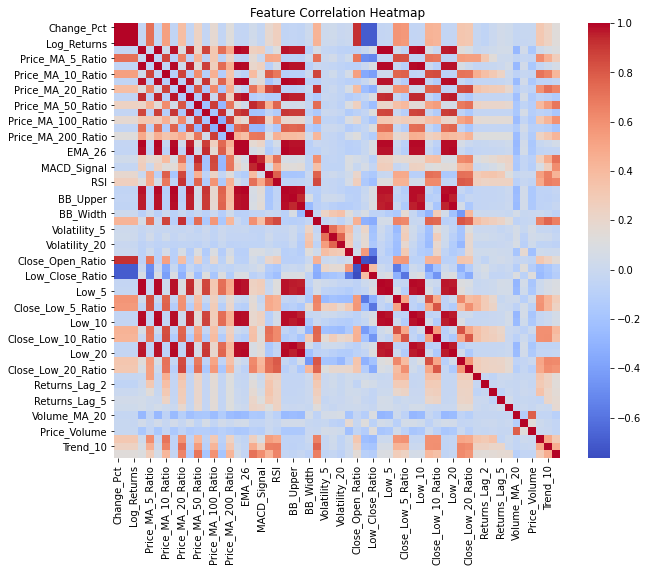

In [20]:
# Set path to store figures
figure_path = r"C:\Users\34663\FRE 7773\project\project\report"

# plot the heatmap for feaature correlaation
corr = X.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

# save the figure
plt.savefig(os.path.join(figure_path, "feature_corr_heatmap.png"), dpi=300, bbox_inches="tight")

plt.show()

In [24]:
high_corr_pairs = [(i, j, corr.loc[i,j]) 
                   for i in corr.columns 
                   for j in corr.columns 
                   if i != j and abs(corr.loc[i,j]) > 0.85]
high_corr_pairs

[('Change_Pct', 'Returns', 0.9999979638458054),
 ('Change_Pct', 'Log_Returns', 0.9999066341303521),
 ('Change_Pct', 'Close_Open_Ratio', 0.9205884836002995),
 ('Returns', 'Change_Pct', 0.9999979638458054),
 ('Returns', 'Log_Returns', 0.9999091044016606),
 ('Returns', 'Close_Open_Ratio', 0.9205703294716785),
 ('Log_Returns', 'Change_Pct', 0.9999066341303521),
 ('Log_Returns', 'Returns', 0.9999091044016606),
 ('Log_Returns', 'Close_Open_Ratio', 0.9204650276268358),
 ('MA_5', 'MA_10', 0.9947363152525786),
 ('MA_5', 'MA_20', 0.9766365622242525),
 ('MA_5', 'MA_50', 0.9327723628874132),
 ('MA_5', 'MA_100', 0.8650235552860349),
 ('MA_5', 'EMA_12', 0.9951116967822528),
 ('MA_5', 'EMA_26', 0.9794597759338309),
 ('MA_5', 'BB_Middle', 0.9766365622242525),
 ('MA_5', 'BB_Upper', 0.9619909352779643),
 ('MA_5', 'BB_Lower', 0.9633427931205119),
 ('MA_5', 'High_5', 0.9957595887321401),
 ('MA_5', 'Low_5', 0.9962104568990438),
 ('MA_5', 'High_10', 0.9861211083397272),
 ('MA_5', 'Low_10', 0.988107426436041

In [ ]:
# Dropped features
X = X.drop(['Increment', 'SMA_10', 'SMA_15', 'SMA_20', 'SMA_30', 'SMA_35', 'SMA_40', 
           'BBANDS_U', 'BBANDS_L', 'MACD_SMA_10', 'MACD_SMA_15', 'MACD_SMA_20', 
           'MACD_SMA_30', 'MACD_SMA_35', 'MACD_SMA_40'], axis=1)